In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy import units as u

In [1]:
home = "/home/aurelien/DAWN/DJA-SEpp"

In [3]:
# This work
with fits.open(f"{home}/fields/full-good_morpho-phot.fits.gz") as hdul:
    good_dja = Table(hdul[1].data)
    good_sersic = Table(hdul[2].data)
    good_BD = Table(hdul[3].data)

In [4]:
print(len(good_sersic), good_sersic.colnames)

342532 ['pixel_centroid_x', 'pixel_centroid_y', 'world_centroid_alpha', 'world_centroid_delta', 'source_id', 'detection_id', 'group_id', 'group_stamp_top', 'group_stamp_left', 'group_stamp_width', 'group_stamp_height', 'source_flags', 'n_detected_pixels', 'n_core_pixel', 'snrratio', 'ellipse_a', 'ellipse_b', 'ellipse_theta', 'ellipse_cxx', 'ellipse_cyy', 'ellipse_cxy', 'area', 'elongation', 'ellipticity', 'fmf_reduced_chi_2', 'fmf_iterations', 'fmf_stop_reason', 'fmf_duration', 'fmf_flags', 'fmf_meta_iterations', 'X_MODEL', 'X_MODEL_err', 'Y_MODEL', 'Y_MODEL_err', 'RA_MODEL', 'RA_MODEL_err', 'DEC_MODEL', 'DEC_MODEL_err', 'RADIUS', 'RADIUS_err', 'AXRATIO', 'AXRATIO_err', 'ANGLE', 'ANGLE_err', 'E1', 'E1_err', 'E2', 'E2_err', 'SERSIC', 'SERSIC_err', 'X_SERSIC', 'X_SERSIC_err', 'DET-IMG_RADIUS', 'DET-IMG_RADIUS_err', 'DET-IMG_AXRATIO', 'DET-IMG_AXRATIO_err', 'DET-IMG_ANGLE', 'DET-IMG_ANGLE_err', 'MAG_MODEL_F115W', 'MAG_MODEL_F115W_err', 'FLUX_MODEL_F115W', 'FLUX_MODEL_F115W_err', 'MAG_MODE

In [5]:
# Structural parameters of galaxies in CANDELS (2012)
with fits.open(f"{home}/external-catalogs/J-ApJS-203-24.fit") as hdul:
    morpho_203_24 = Table(hdul[1].data)

In [6]:
morpho_203_24 = morpho_203_24[morpho_203_24['Q']==0]

In [7]:
print(len(morpho_203_24), morpho_203_24.colnames)

139801 ['ID', 'RAJ2000', 'DEJ2000', 'Q', 'mag', 'r', 'e_r', 'n', 'e_n', 'S_N', 'recno']


In [54]:
# Structural parameters of galaxies in CANDELS (2012) (2)
morpho_candels = pd.concat([pd.read_csv(f"{home}/{filename}",
                                delim_whitespace=True, comment="#", header=None, index_col=0,
                                names = ['RA', 'DEC', 'f', 'mag', 'dmag', 're', 'dre', 'n', 'dn', 'q', 'dq', 'pa', 'dpa', 'sn'])
                            for filename in ["external-catalogs/cos_2epoch_wfc3_f160w_060mas_v1.0_galfit.cat",
                                             "external-catalogs/egs_2epoch_wfc3_f160w_060mas_v0.8_galfit.cat",
                                             "external-catalogs/uds_2epoch_wfc3_f160w_060mas_v0.3_galfit.cat",
                                             "external-catalogs/gn_all_candels_wfc3_f160w_060mas_v0.8_galfit.cat",
                                             "external-catalogs/gs_all_candels_ers_udf_f160w_v0.5_galfit.cat",]])

/tmp/ipykernel_7343/3414571746.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  morpho_candels = pd.concat([pd.read_csv(f"{home}/{filename}",
/tmp/ipykernel_7343/3414571746.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  morpho_candels = pd.concat([pd.read_csv(f"{home}/{filename}",
/tmp/ipykernel_7343/3414571746.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  morpho_candels = pd.concat([pd.read_csv(f"{home}/{filename}",
/tmp/ipykernel_7343/3414571746.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  morpho_candels = pd.concat([pd.read_csv(f"{home}/{filename}",
/tmp/ipykernel_7343/34145717

In [55]:
morpho_candels = morpho_candels[morpho_candels['f']==0]

In [56]:
print(len(morpho_candels), list(morpho_candels.columns))

112103 ['RA', 'DEC', 'f', 'mag', 'dmag', 're', 'dre', 'n', 'dn', 'q', 'dq', 'pa', 'dpa', 'sn']


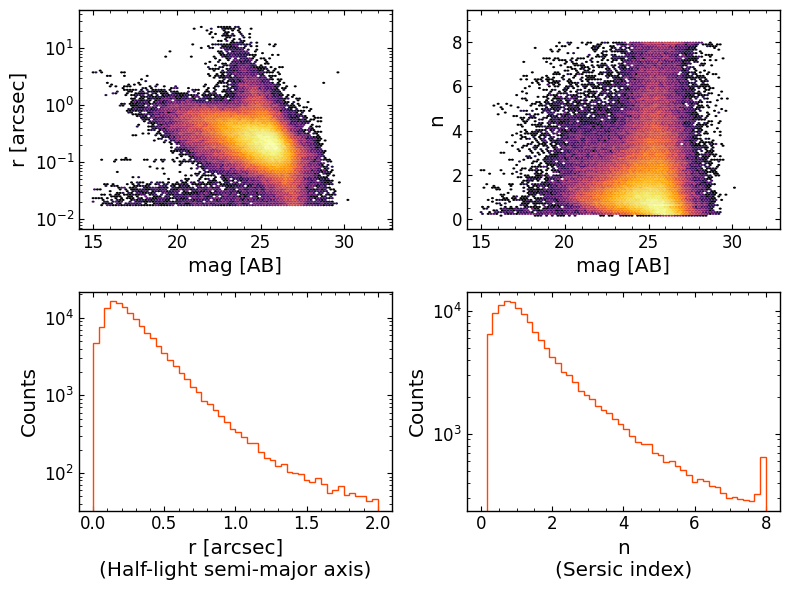

In [62]:
# Structural parameters of galaxies in CANDELS (2012)
fig, axs = plt.subplots(2,2, figsize=(8,6))

axs[0,0].hexbin(morpho_203_24['mag'], morpho_203_24['r'], mincnt=1, gridsize=100, cmap='inferno', bins='log', yscale='log', extent=(15,32,-2,1.5), lw=0.01)
axs[0,0].set_xlabel("mag [AB]")
axs[0,0].set_ylabel("r [arcsec]")

axs[0,1].hexbin(morpho_203_24['mag'], morpho_203_24['n'], mincnt=1, gridsize=100, cmap='inferno', bins='log', extent=(15,32,0,9), lw=0.01)
axs[0,1].set_xlabel("mag [AB]")
axs[0,1].set_ylabel("n")

axs[1,0].hist(morpho_203_24['r'], bins=50, range=(0,2), histtype='step', log=True, color='orangered')
axs[1,0].set_xlabel("r [arcsec]\n(Half-light semi-major axis)")
axs[1,0].set_ylabel("Counts")

axs[1,1].hist(morpho_203_24['n'], bins=50, range=(0,8), histtype='step', log=True, color='orangered')
axs[1,1].set_xlabel("n\n(Sersic index)")
axs[1,1].set_ylabel("Counts")

fig.tight_layout()
plt.show()

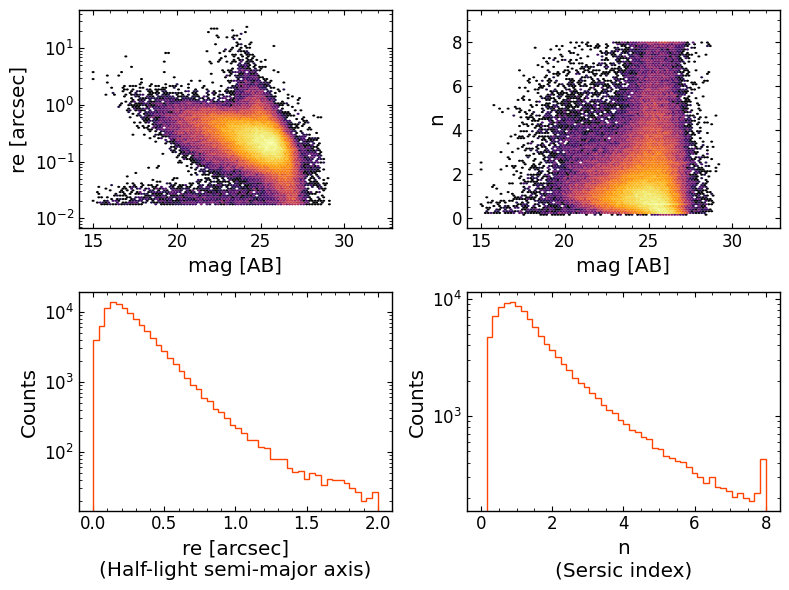

In [63]:
# Structural parameters of galaxies in CANDELS (2012) (2)
fig, axs = plt.subplots(2,2, figsize=(8,6))

axs[0,0].hexbin(morpho_candels['mag'], morpho_candels['re'], mincnt=1, gridsize=100, cmap='inferno', bins='log', yscale='log', extent=(15,32,-2,1.5), lw=0.01)
axs[0,0].set_xlabel("mag [AB]")
axs[0,0].set_ylabel("re [arcsec]")

axs[0,1].hexbin(morpho_candels['mag'], morpho_candels['n'], mincnt=1, gridsize=100, cmap='inferno', bins='log', extent=(15,32,0,9), lw=0.01)
axs[0,1].set_xlabel("mag [AB]")
axs[0,1].set_ylabel("n")

axs[1,0].hist(morpho_candels['re'], bins=50, range=(0,2), histtype='step', log=True, color='orangered')
axs[1,0].set_xlabel("re [arcsec]\n(Half-light semi-major axis)")
axs[1,0].set_ylabel("Counts")

axs[1,1].hist(morpho_candels['n'], bins=50, range=(0,8), histtype='step', log=True, color='orangered')
axs[1,1].set_xlabel("n\n(Sersic index)")
axs[1,1].set_ylabel("Counts")

fig.tight_layout()
plt.show()

In [59]:
coord_sersic = SkyCoord(ra=good_sersic['world_centroid_alpha'], dec=good_sersic['world_centroid_delta'], unit='deg')
# coord_203_24 = SkyCoord(ra=morpho_203_24['RAJ2000'], dec=morpho_203_24['DEJ2000'], unit='deg')
coord_candels = SkyCoord(ra=morpho_candels['RA'], dec=morpho_candels['DEC'], unit='deg')

In [60]:
# idx_203_24, d2d_203_24, d3d_203_24 = coord_sersic.match_to_catalog_sky(coord_203_24)
idx_candels, d2d_candels, d3d_candels = coord_sersic.match_to_catalog_sky(coord_candels)

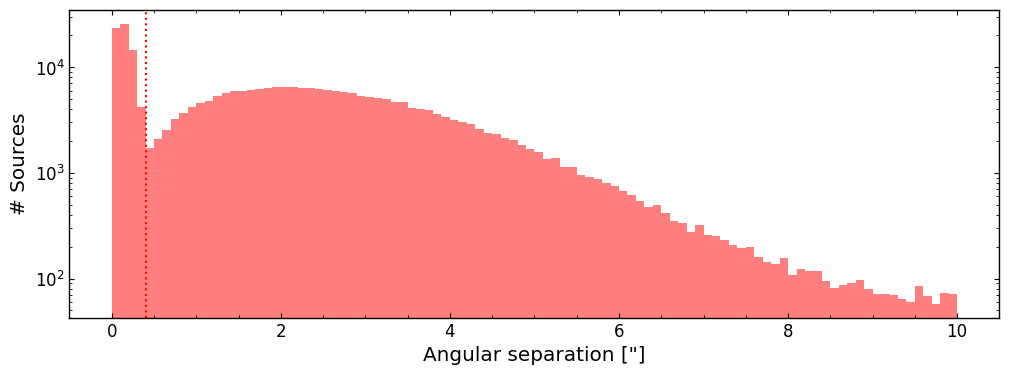

In [61]:
max_sep = 0.4*u.arcsec

fig, ax = plt.subplots(figsize=(12,4))
# ax.hist(d2d_203_24.to(u.arcsec), bins=100, range=(0*u.arcsec,10*u.arcsec), color='k')
ax.hist(d2d_candels.to(u.arcsec), bins=100, range=(0*u.arcsec,10*u.arcsec), color='r', alpha=0.5)
ax.axvline(max_sep.to_value(u.arcsec), color='r', ls=':')
ax.set_yscale('log')
ax.set_xlabel('Angular separation ["]')
ax.set_ylabel('# Sources')
plt.show()

In [65]:
# morpho_203_24_match = morpho_203_24[idx_203_24][d2d_203_24<max_sep]
morpho_candels_match = morpho_candels.iloc[idx_candels[d2d_candels<max_sep]]
# sersic_match = good_sersic[d2d_203_24<max_sep]
sersic_match = good_sersic[d2d_candels<max_sep]

In [66]:
len(sersic_match)

67820

In [68]:
def correct_radius(R_0, lambda_0, lambda_1, z, mass):
    # color_grad = -0.35 + 0.12*z - 0.25*np.log10(mass/1e10)
    color_grad = -0.25
    delta_log_R = color_grad * np.log10(lambda_1/lambda_0)
    return R_0 * np.power(10, delta_log_R)

In [82]:
# R_0 = morpho_203_24_match['r']
R_0 = morpho_candels_match['re']
lambda_0 = 0.5
lambda_1 = 2.5
z = good_dja['z_phot'][d2d_candels<max_sep]
mass = good_dja['mass'][d2d_candels<max_sep]
corrected_R = correct_radius(R_0, lambda_0, lambda_1, z, mass)

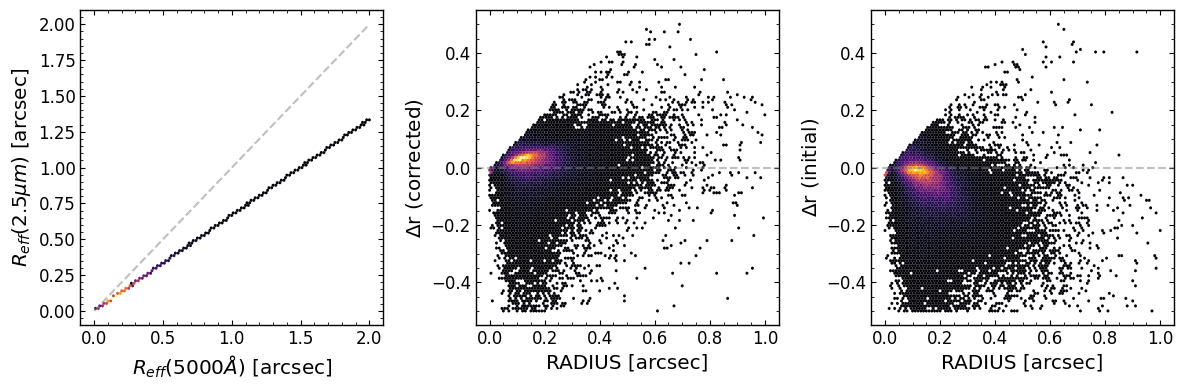

In [83]:
fig, axs = plt.subplots(1,3, figsize=(12,4))

bins = None # None or 'log'

axs[0].hexbin(morpho_candels_match['re'], corrected_R, mincnt=1, gridsize=100, cmap='inferno', bins=bins, extent=(0,2,0,2), lw=0.01)
axs[0].plot([0,2],[0,2], color='gray', ls='--', alpha=0.5)
axs[0].set_xlabel("$R_{eff}(5000\AA)$ [arcsec]")
axs[0].set_ylabel(f"$R_{{eff}}({lambda_1:.1f}µm)$ [arcsec]")

axs[1].hexbin(sersic_match['RADIUS']*3600, sersic_match['RADIUS']*3600-corrected_R, mincnt=1, gridsize=100, cmap='inferno', bins=bins, extent=(0,1,-0.5,0.5), lw=0.01)
axs[1].axhline(0, color='gray', ls='--', alpha=0.5)
axs[1].set_xlabel("RADIUS [arcsec]")
axs[1].set_ylabel("$\Delta$r (corrected)")

axs[2].hexbin(sersic_match['RADIUS']*3600, sersic_match['RADIUS']*3600-morpho_candels_match['re'], mincnt=1, gridsize=100, cmap='inferno', bins=bins, extent=(0,1,-0.5,0.5), lw=0.01)
axs[2].axhline(0, color='gray', ls='--', alpha=0.5)
axs[2].set_xlabel("RADIUS [arcsec]")
axs[2].set_ylabel("$\Delta$r (initial)")

fig.tight_layout()
plt.show()

/tmp/ipykernel_7343/3469367592.py:6: RuntimeWarning: divide by zero encountered in divide
  cond = (sersic_match['FLUX_MODEL_F277W']/sersic_match['FLUX_MODEL_F277W_err'] > 10 ) & (sersic_match['RADIUS']>0) & (morpho_candels_match['re']>0) & (morpho_candels_match['n']>0) & (morpho_candels_match['q']>0)


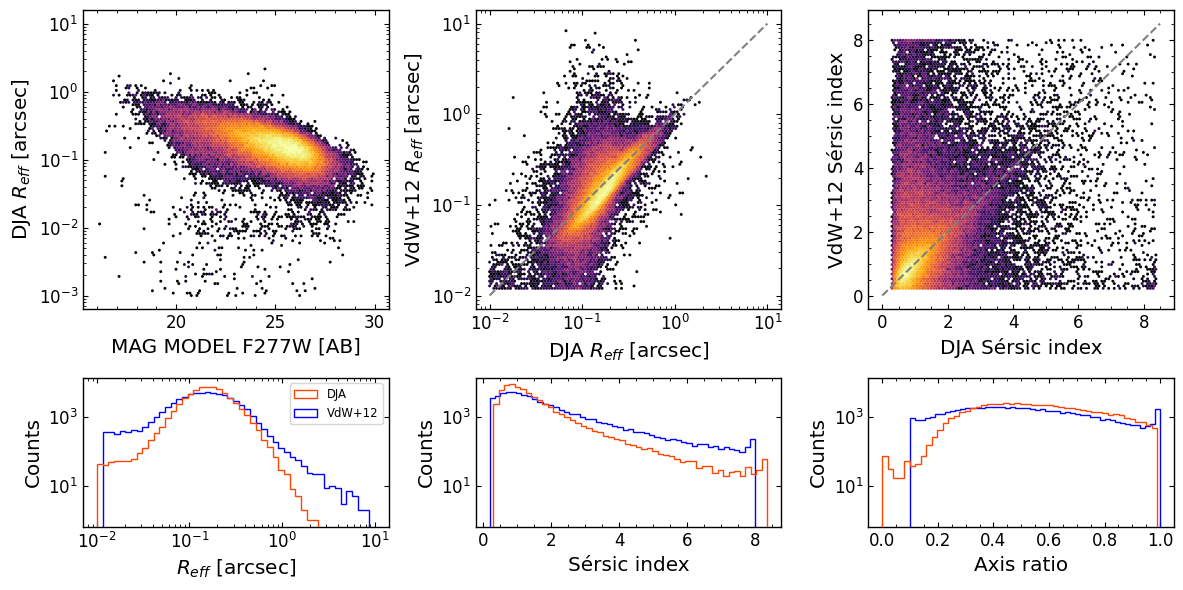

In [87]:
# Structural parameters of galaxies in CANDELS (2012) (2)
fig = plt.figure(figsize=(12,6))
gs = fig.add_gridspec(2, 3, height_ratios=[2,1])

bins = 'log' # None or 'log
cond = (sersic_match['FLUX_MODEL_F277W']/sersic_match['FLUX_MODEL_F277W_err'] > 10 ) & (sersic_match['RADIUS']>0) & (morpho_candels_match['re']>0) & (morpho_candels_match['n']>0) & (morpho_candels_match['q']>0)

ax = fig.add_subplot(gs[0,0])
ax.hexbin(sersic_match['MAG_MODEL_F277W'][cond], sersic_match['RADIUS'][cond]*3600, mincnt=1, yscale='log', gridsize=100, cmap='inferno', bins=bins, extent=(16,30,-3,1), lw=0.01)
ax.set_xlabel("MAG MODEL F277W [AB]")
ax.set_ylabel("DJA $R_{eff}$ [arcsec]")

ax = fig.add_subplot(gs[0,1])
ax.hexbin(sersic_match['RADIUS'][cond]*3600, corrected_R[cond], mincnt=1, xscale='log', yscale='log', gridsize=100, cmap='inferno', bins=bins, extent=(-2,1,-2,1), lw=0.01)
ax.plot([1e-2, 10], [1e-2, 10], color='gray', ls='--', alpha=1.0)
ax.set_xlabel("DJA $R_{eff}$ [arcsec]")
ax.set_ylabel("VdW+12 $R_{eff}$ [arcsec]")

ax = fig.add_subplot(gs[0,2])
ax.hexbin(sersic_match['SERSIC'][cond], morpho_candels_match['n'][cond], mincnt=1, gridsize=100, cmap='inferno', bins=bins, extent=(0,8.5,0,8.5), lw=0.01)
ax.plot([0,8.5], [0,8.5], color='gray', ls='--', alpha=1.0)
ax.set_xlabel("DJA Sérsic index")
ax.set_ylabel("VdW+12 Sérsic index")

ax = fig.add_subplot(gs[1,0])
ax.hist(sersic_match['RADIUS'][cond]*3600, bins=np.logspace(-2, 1, 50), zorder=10, histtype='step', log=True, color='orangered', label='DJA')
ax.hist(corrected_R[cond], bins=np.logspace(-2, 1, 50), histtype='step', log=True, color='blue', label='VdW+12')
ax.set_xscale('log')
ax.set_xlabel("$R_{eff}$ [arcsec]")
ax.set_ylabel("Counts")
ax.legend(loc='upper right', fontsize='small')

ax = fig.add_subplot(gs[1,1], sharey=ax)
ax.hist(sersic_match['SERSIC'][cond], zorder=10, bins=50, histtype='step', log=True, color='orangered', label='DJA')
ax.hist(morpho_candels_match['n'][cond], bins=50, histtype='step', log=True, color='blue', label='VdW+12')
ax.set_xlabel("Sérsic index")
ax.set_ylabel("Counts")
# ax.legend(loc='upper right', fontsize='small')

ax = fig.add_subplot(gs[1,2], sharey=ax)
ax.hist(sersic_match['AXRATIO'][cond], zorder=10, bins=50, histtype='step', log=True, color='orangered', label='DJA')
ax.hist(morpho_candels_match['q'][cond], bins=50, histtype='step', log=True, color='blue', label='VdW+12')
ax.set_xlabel("Axis ratio")
ax.set_ylabel("Counts")
# ax.legend(loc='upper right', fontsize='small')

fig.tight_layout()
fig.savefig(f"{home}/fields/VdW_morpho_comparison.png", dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [88]:
len(np.where(cond)[0])

66529